# 3. 그리디 알고리즘

# 참고
[(이코테 2021 강의 몰아보기) 2. 그리디 & 구현
](https://www.youtube.com/watch?v=2zjoKjt97vQ&list=PLRx0vPvlEmdAghTr5mXQxGpHjWqSz0dgC&index=2)

## lecture 12. 그리디 알고리즘 개요

### 그리디 알고리즘

그리디 알고리즘(탐욕법)은 **현재 상황에서 지금 당장 좋은 것만 고르는 방법**을 의미한다.

일반적이 그리디 알고리즘은 문제를 풀기 위한 최소한의 아이디어를 떠올릴 수 있는 능력을 요구한다. 

그리디 해법은 그 정당성 분석이 중요하다. 따라서, 단순히 가장 좋아보이는 것을 반복적으로 선택해도 최적의 해를 구할 수 있는지 검토해야한다.

### 그리디 알고리즘의 문제

다음의 문제를 생각해보자.

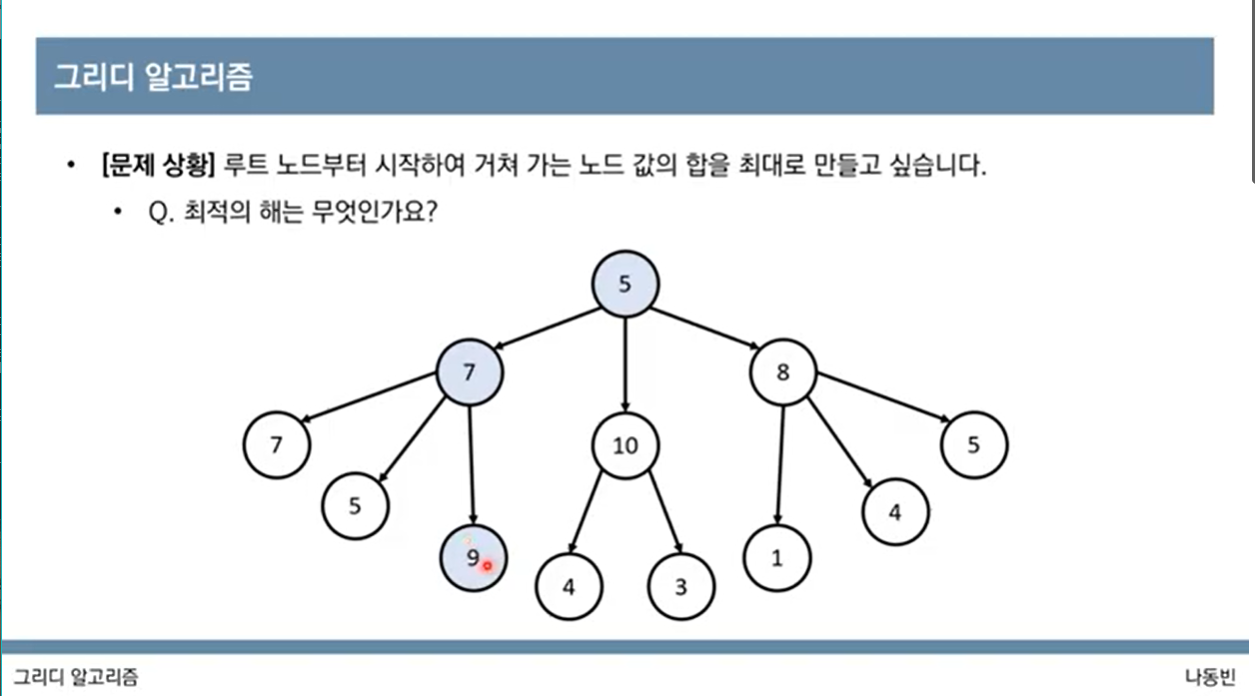

만약 그리디 알고리즘을 이용한다면 오답을 선택할 수 있다. 

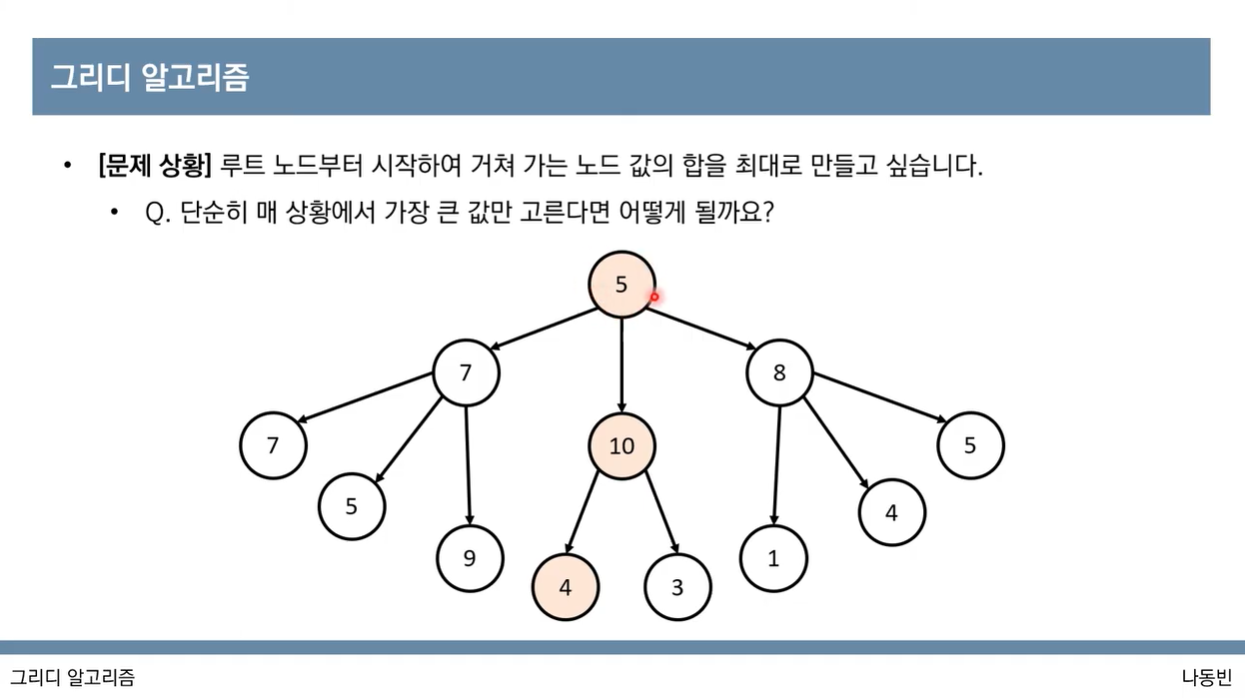

이처럼 일반적인 상황에서 그리디 알고리즘은 최적의 해를 보장할 수 없을 때가 많다. 하지만, 코딩 테스트에서 대부분의 그리디 문제는 **탐욕법으로 얻은 해가 최적의 해가 되는 상황에서, 이를 추론할 수 있어야 풀리도록** 출제된다.


### <문제>

#### 거스름 돈 : 문제 설명

당신은 음식점의 계산을 도와주는 점원입니다. 카운터에는 거스름돈으로 사용할 500원, 100원, 50원, 10원짜리 동전이 무한히 존재한다고 가정힙니다. 손님에게 거슬러 주어야 할 돈이 N원일 때 거슬러 주어야 할 동전의 최소 개수를 구하세요. 단, 거슬러 줘야 할 돈 N은 항상 10의 배수입니다.

##### 거스름 돈 : 문제 해결 아이디어

최적의 해를 빠르게 구하기 위해서는 **가장 큰 화폐 단위부터** 돈을 거슬러 주면 된다.
N원을 거슬러 줘야 할 때, 가장 먼저 500원으로 거슬러 줄 수 있을 만큼 거슬러 주고 이후에 100원, 50원, 10원짜리 동전을 차례대로 거슬러 줄 수 있을 만큼 거슬러 주면 된다.

1260원으로 예시를 들어 보자.

1260 = 500 * 2 + 260
260 = 100 * 2 + 60
60 = 50 * 1 + 10
10 = 10 * 1 + 0

##### 거스름 돈 : 정당성 분석

가장 큰 화폐부터 돈을 거슬러 주는 것이 최적의 해를 보장하는 이유는 무엇일까?

그 이유는 가지고 있는 동전 중에서 **큰 단위가 항상 작은 단위의 배수이므로 작은 단위의 동전들을 종합해 다른 해가 나올 수 없기 때문**이다.

만약 800원을 거슬러 주어야 하는데 화폐 단위가 500원, 400원, 100원이라면 (500원 1개, 100원 3개)가 아닌 (400원 2개)가 최적의 해이다. 900원을 거슬러 주는 경우는 (400원 2개, 100원 1개)가 아닌 (500원 1개, 400원 1개)가 최적의 해이다.

그리디 알고리즘 문제에서는 이처럼 문제 풀이를 위한 최소한의 아이디어를 더올리로 이것이 정당한지 검토할 수 있어야 한다.

##### 거스름 돈 : 답안

```python
n = input()
count = 0

# 큰 단위의 화폐부터 차례대로 확인하기
array = [500, 100, 50, 10]

for coin in array:
    count += n //coin # 해당 화폐로 거글러 줄 수 있는 동전의 개수 세기
    n %= coin

print(count)
```

##### 거스름 돈 : 시간 복잡도 분석

화폐의 종류가 K라고 할 때, 소스코드의 시간 복잡도는 O(K)이다.
이 알고리즘의 시간 복잡도는 거슬러줘야 하는 금액과 무관하며, 동전의 총 종류에만 영향을 받기 때문이다.

## lecture 13. 그리디 유형 문제 풀이


### 1이 될 때까지 : 문제 설명

어떤 수 N이 1이 될 때까지 다음의 두 과정 중 하나르 반복적으로 선택하여 수행하려고 한다. 단, 두 번째 여산은 N이 K로 나누어 떨어질 때만 선택할 수 있다.

1. N에서 1을 뺀다.
2. N을 K로 나눈다.

예를 들어 N=17, K=4라고 가정하자. 이때 1번의 과정을 한 번 수행하면 N은 16이 된다. 이후에 2번의 과정을 두번 수행하면 N은 1이된다. 결과적으로 이 경우 전체 과정을 시행한 횟수는 3이 된다. 이는 N을 1로 만드는 최소 횟수이다.

N과 K가 주어질 때 N이 1이 될 때까지 1번 혹은 2번의 과정을 수행해야 하는 최소 횟수를 구하는 프로그램을 작성하시오.

풀이 시간 15분, 시간제한 2초, 메모리 제한 128M

입력 조건 : 첫째 줄에 N(1 <= N <= 100,000)과 K(2 <= K <= 100,000)가 공백을 기준으로 하여 각각 자연수로 주어진다.

출력 조건 : 천째 줄에 N이 1이 될 때까지 1번 혹은 2번의 과정을 수행해야 하는 횟수의 최솟값을 출력한다.

입력 예시 : 25 2
출력 예시 : 2

#### 1이 될 때까지 : 문제 해결 아이디어

N이 K로 나누어질 때까지 나누고 나누어지지 않을 때 1을 뺀다. 이 과정을 반복한다.

단, N=1, K=1이라면 답은 0
N=K라면 2번 과정 1번만 수행한다. 
N>K, K=1이라면 1번과정만 반복한다. 

#### 1이 될 때까지 : 정당성 분석

N>K 라면, 2번 과정은 1번 과정보다 1에 더 빨리 가까워지는 방법이다. N = MK라면 N-M > 1이기 때문이다.

#### 1이 될 때까지 : 답안

```python
N, K = map(int, input().split())
i = 0
      
if N == K:
    if N == 1:
        result = 0
    else:
        result = 1
else:
    if K == 1:
        result = N-1
    else:
        while N != 1 & i < N:
            if N % K == 0:
                N = N // K
            else:
                N -= 1
            i += 1
      
print(result)
```
          
      



In [16]:
N, K = map(int, input().split())
i = 0
      
if N == K:
    if N == 1:
        i = 0
    else:
        i = 1
else:
    while N != 1 and i < N:
        if N % K == 0:
            N = N // K
        else:
            N -= 1
        i += 1
            
print(i)

N,K 값을 넣으시오.: 예시) 12 5
25 5
2


#### 1이 될 때까지 : 저자 답안 예시

```python
# N, K를 공백을 기준으로 구분하여 입력 받기
n,k = map(int, inputO.split())

result = 0

while True:
    # N이 K로 나누어 떨어지는 수가 될 때까지 빼기
    target = (n//k) * k
    result += (n-target)
    n = target
    # N이 K보다 작을 때(더 이상 나눌 수 없을 때) 반복을 탈출
    if n < k:
        break
    # K로 나누기
    n //= k
    
# 마지막으로 남은 수에 대하여 1씩 빼기
result += (n-1)
print(result)
```

이 답안의 장점 n이 빠르게 줄어들음 시간 복잡도가 logN임.


### 곱하기 혹은 더하기 : 문제 설명

각 자리가 숫자(0부터9)로만 이루어진 문자열 S가 주어졌을 때, 왼쪽부터 오른쪽으로 하나씩 모든 숫자를 확인하며 숫자 사이에 'x' 혹은 '+'연산자를 넣어 결과적으로 만들어질 수 있는 가장 큰 수를 구하는 프로그램을 작성하세요. 단, +보다 X를 먼저하는 일반적인 방식과는 달리, 모든 연산은 왼쪽에서부터 순서대로 이루어진다고 가정합니다.

예를 들어 02984라는 문자열로 만들 수 있는 가장 큰 수는 ((((0+2)x9)x8)x4)=576입니다. 또한 만들어질 수 있는 가장 큰 수는 항상 20억 이하의 정수가 되도록 입력이 주어집니다.

난이도 : 하, 풀이 시간 30분, 시간 제한 1초, 메모리 제한 128MB

입력 조건 : 첫째 줄에 여러 개의 숫자로 구성된 하나의 문자열 S가 주어집니다.(1<= S의 길이 <= 20)
출력 조건 : 첫째 줄에 만들어질 수 있는 가장 큰 수를 출력합니다.

#### 곱하기 혹은 더하기 : 문제 해결 아이디어

0,1이 나오면 + 나머지는 x로 계산한다.

#### 곱하기 혹은 더하기 : 정당성 분석

0은 곱하면 0, 1은 곱하면 무조건 자기 자신이므로 더하는 것이 곱하는 것보다 작다.
2 이상부터는 곱하는 것이 더하는 것보다 크거나 같다.

#### 답안


In [13]:
num = input()

n = len(num)
num_list = []

for i in range(n):
    num_list.append(int(num[i]))
                    
result = num_list[0]

for i in range(1,n):
    if result==0 or num_list[i]==0 or num_list[i] ==1:
        result += num_list[i]
    else:
        result *= num_list[i]

print(result)

# 풀이 시간 약 40분

567
210


#### 저자의 문제 해결 아이디어

대부분의 경우 '+'보다는 'x'가 더 값을 크게 만든다.
* 예를 들어 5+6=11, 5x6=30

다만 두 수 중에서 하나라도 '0' 혹은 '1'인 경우, 곱하기보다는 더하기를 수행하는 것이 효율적이다.

따라서, 두 수에 대하여 연산을 수행할 때, 두 수 중에서 하나라도 1 이하인 경우네느 더하며, 두 수가 모두 2 이상인 경우네는 곱하면 정답이다.

```python
data = input()

# 첫 번째 문자를 숫자로 변경하여 대입
result = int(data[0])

for i in range(1, len(data)):
    # 두 수 중에서 하나라도 '0' 혹은 '1'인 경우, 곱하기보다는 더하기 수행
    num = int(data[i])
    if num <= 1 or result <= 1:
        result += num
    else:
        result *= num
        
print(result)
```

#### 생각 다듬기

나는 두 수 중에서 하나라도 0 혹은 1인 경우에 대해서 나눠서 했지만, 저자는 하나로 묶어버림.


### 모험가 길드 : 문제 설명

한 마음에 모험가가 N명 있습니다. 모험가 길드에서는 N명의 모험가를 대상으로 '공포도'를 측정했는데, '공포도'가 높은 모험가는 쉽게 공포를 느껴 위험 상황에서 제대로 대처할 능력이 떨어집니다.

모험가 길드장인 동빈이는 모험가 그룹을 안전하게 구성하고자 공포도가 X인모험가는 반드시 X명 이상으로 구성한 모험가 그룹에 참여해야 여행ㅇ르 떠날 수 있도록 규정했다.

동빈이는 최대 몇 개의 모험가 그룹을 만들 수 있는지 궁금하다. N명의 모험가에 대한 정보가 주어졌을 때, 여행을 떠날 수있는 그룹 수의 최댓값을 구하는 프로그램을 작성하시오.

예를 들어 N=5이고, 각 모험가의 공포도가 다음과 같다고 가정합시다.

* 2 3 1 2 2

이 경우 그룹 1에 공포도가 1, 2, 3인 모험가를 한 명씩 넣고, 그룹 2에 공포도가 2인 남은 두 명을 넣게 되면 총 2개의 그룹을 만들 수 있다.

또한 몇 명의 모험가는 마을에 그대로 남아 있어도 되기 때문에, 모든 모험가를 특정한 그룹에 넣을 필요는 없다.

난이도 : 하, 풀이 시간 : 30분, 시간 제한 1초, 메모리 제한 128MB

입력 조건 : 첫째 줄에 모험가의 수 N이 주어진다.(1 <= N <= 100,000), 
둘 째 줄에 각 모험가의 공포도 값을 N 이하의 자연수로 주어지면, 각 자연수는 공백으로 구분한다.

출력 조건 : 여행을 떠날 수 있는 그룹 수의 최댓값을 출력한다.

#### 모험가 길드 : 문제 해결 아이디어
12: 26시작


1. 같은 공포도끼리 그룹을 만든다.
2. 나머지 모험가를 모아서 내림순으로 정렬한다.
3. 가장 앞에 있는 수와 남은 모험가 수를 비교해서 모험가 수가 많으면 그룹을 만든다.
4. 2-3을 반복한다.

#### 모험가 길드 : 정당성 분석

같은 공포도끼리 보내고 남은 인원으로 하는 게 최대 그룹수를 만든다. 공포도가 큰 모험가가를 위해서 작은 모험가가 희생될 수 있다.


#### 모험가 길드 : 정당성 분석



In [22]:
# 12: 32 시작
N = map(int, input())
fear = list(map(int,input().split()))
fear.sort()

fear_set = set(fear)

group = 0
rest = []

for i in fear_set:
    n = fear.count(i)
    group += n // i
    rest + [i]*(n%i)

rest_set = set(rest)

for i in rest_set:
    if len(rest) > i: 
        group +=1
    else:
        rest = [x for x in rest if x != i]
print(group)
# 1시 01분 끝

5
2 3 1 2 2
2


[5, 9, 0]

#### 저자의 문제해결 아이디어

오름차순 정렬 이후에 공포도가 가장 낮은 모험가부터 하나씩 확인한다.

앞에서부터 공포도를 하나씩 확인하며 '현재 그룹에 포험된 모험가의 수'가 '현재 확인하고 있는 공포도'보다 크거나 같다면 이를 그룹으로 설정하면 된다.

이러한 방법을이용하면 공포도가 오름차순으로 정렬되어 있ㄷ는 점에서, 항상 최소한의 모험가의 수만 포함하여 그룹을 결성하게 된다.

```python

n = int(input())
data = list(map(int, input().split()))
data.sort()

result = 0 # 총 그룹의 수
count = 0 # 현재 그룹에 포함된 모험가의 수

for i in data: # 공포도를 낮은 것부터 하나씩 확인하며
    count += 1 # 현재 그룹에 해당 모험가를 포함시키기
    if count >= i : # 현재 그룹에 포함된 모험가의 수가 현재의 공포도 이상이라면, 그룹 결성
        result += 1 # 총 그룹의 수 증가시키기
        count = 0 # 현재 그룹에 포함된 모험가의 수 초기화
        
print(result)
```

####  배운점

map 사용법